# EJERCICIO: Correlación de variables (ejemplo 1)

In [ ]:
# Módulo 4 sesión 3
# EJEMPLO: Relación entre estudio, celular y rendimiento académico
# ======================================# Paso 1: Importar librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Paso 2: Simular los datos
np.random.seed(42)  # Para reproducibilidad
# Una semilla es un valor inicial que se le da al algoritmo de generación de números aleatorios
# para que siempre produzca la misma secuencia de valores aleatorios cada vez que ejecutes el código.
# Si compartes tu código con otra persona (o lo ejecutas tú más tarde), los resultados serán exactamente iguales.
# Muy importante en ciencia de datos, estadísticas y machine learning, donde los resultados deben poder replicarse.



n = 50  # número de estudiantes

# Simulamos los datos
horas_estudio = np.random.normal(5, 2, n).clip(0)        # media=5 horas, min 0
uso_celular = np.random.normal(3, 1.2, n).clip(0)        # media=3 horas, min 0
# La función .clip(0) en este contexto está siendo usada para asegurar que ningún valor
# sea menor que 0, es decir, trunca todos los valores negativos y los reemplaza por 0.

# Nxºota dependerá de horas de estudio (más horas, mejor nota) y uso del celular (más celular, peor nota)
nota = (horas_estudio * 1.5) - (uso_celular * 1.0) + np.random.normal(0, 1, n)
# para agregar un componente aleatorio con distribución normal.
# Es una forma de agregar ruido realista o variabilidad natural al modelo.
# ¿Por qué agregar ruido aleatorio?
# Porque en la vida real:
# Dos estudiantes que estudian lo mismo y usan el celular igual no sacarán necesariamente la misma nota.
# Existen factores no observados que influyen (dormir bien, estrés, salud, suerte, tipo de examen, etc.).
# Ese término normal simula esa variabilidad natural.
nota = nota.clip(1, 7)  # escala de notas de 1 a 7

# Crear el DataFrame
df = pd.DataFrame({
    'horas_estudio': horas_estudio,
    'uso_celular': uso_celular,
    'nota': nota
})

# Paso 3: Mostrar los primeros datos
print(df.head())


    horas_estudio  uso_celular      nota
0        5.993428     3.388901  4.185871
1        4.723471     2.537901  4.126661
2        6.295377     2.187694  6.912657
3        8.046060     3.734012  7.000000
4        4.531693     4.237199  2.399055
5        4.531726     4.117536  3.084104
6        8.158426     1.992939  7.000000
7        6.534869     2.628945  7.000000
8        4.061051     3.397516  2.951611
9        6.085120     4.170654  4.882580
10       4.073165     2.424991  1.765985
11       4.068540     2.777209  3.299088
12       5.483925     1.672398  6.613719
13       1.173440     1.564552  2.658849
14       1.550164     3.975031  1.000000
15       3.875425     4.627488  1.487197
16       2.974338     2.913588  1.513207
17       5.628495     4.204239  3.069824
18       3.183952     3.433963  2.484787
19       2.175393     2.225856  1.789166
20       7.931298     3.433675  7.000000
21       4.548447     4.845644  1.067640
22       5.135056     2.957009  6.148370
23       2.15050

In [ ]:
# Categorizar uso del celular (bajo, medio, alto)
df['uso_celular_cat'] = pd.cut(df['uso_celular'], bins=[0, 2, 4, 10], labels=['Bajo', 'Medio', 'Alto'])

# Categorizar nota (baja <4, buena 4-6, alta >6)
df['nota_cat'] = pd.cut(df['nota'], bins=[0, 4, 6, 7], labels=['Baja', 'Buena', 'Alta'])

# Tabla de contingencia
tabla = pd.crosstab(df['uso_celular_cat'], df['nota_cat'])
print("\nTabla de contingencia:")
print(tabla)



Tabla de contingencia:
nota_cat         Baja  Buena  Alta
uso_celular_cat                   
Bajo                1      2     2
Medio              19      4    11
Alto                8      2     0


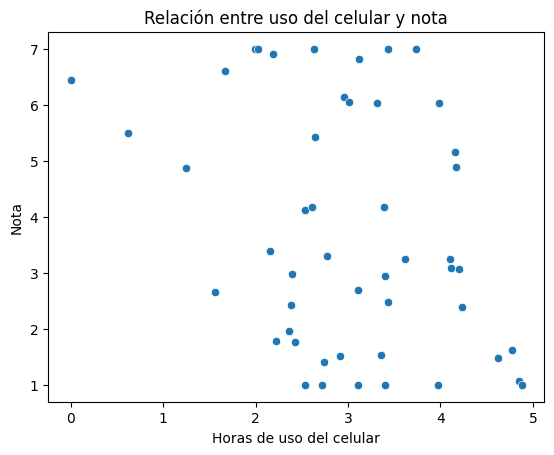

In [ ]:
# Diagrama de dispersión
sns.scatterplot(data=df, x='uso_celular', y='nota')
plt.title("Relación entre uso del celular y nota")
plt.xlabel("Horas de uso del celular")
plt.ylabel("Nota")
plt.show()

In [ ]:
# Cálculo de la correlación
correlacion = df['uso_celular'].corr(df['nota'])
print(f"\nCoeficiente de correlación entre uso del celular y nota: {correlacion:.2f}")


Coeficiente de correlación entre uso del celular y nota: -0.32


# EJERCICIO: Correlación de variables (ejemplo 2)

In [ ]:
# A medida que aumenta el consumo de helado, también aumentan los incendios.
# Pero comer helado NO causa incendios — ambos aumentan por una tercera variable: el calor (verano).
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Simular datos
np.random.seed(0)
n = 50  # número de observaciones (por ejemplo, días de verano)

# Tercera variable: temperatura
temperatura = np.random.normal(30, 3, n)  # grados Celsius

# Variable 1: consumo de helado (más calor → más helado)
helados = temperatura * 1.5 + np.random.normal(0, 2, n)

# Variable 2: número de incendios (más calor → más incendios forestales)
incendios = temperatura * 0.8 + np.random.normal(0, 1, n)

# Crear DataFrame
df = pd.DataFrame({
    'temperatura': temperatura,
    'consumo_helado': helados,
    'incendios': incendios
})

# Mostrar primeros datos
print(df.head())

   temperatura  consumo_helado  incendios
0    35.292157       51.147302  30.116876
1    31.200472       47.574512  23.612618
2    32.936214       48.382711  25.078486
3    36.722680       52.722755  30.347540
4    35.602674       53.347646  27.309016


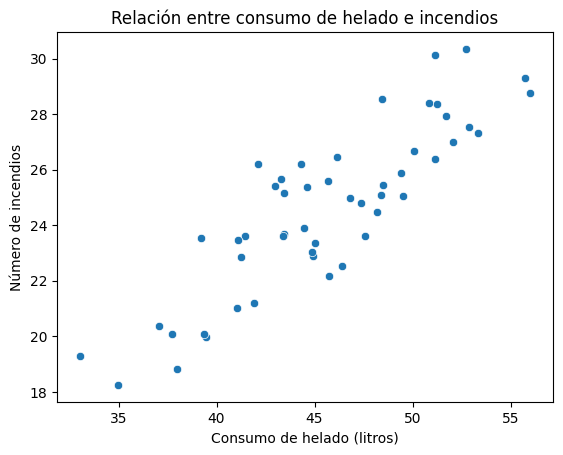

In [ ]:
# Graficar la relación entre consumo de helado e incendios
sns.scatterplot(x='consumo_helado', y='incendios', data=df)
plt.title("Relación entre consumo de helado e incendios")
plt.xlabel("Consumo de helado (litros)")
plt.ylabel("Número de incendios")
plt.show()


In [ ]:
# Calcular coeficiente de correlación
corr = df['consumo_helado'].corr(df['incendios'])
print(f"\nCoeficiente de correlación: {corr:.2f}")
# Es probable que veas una correlación positiva fuerte (por ejemplo, 0.8).
# Pero comer más helado no causa incendios. La temperatura es la variable oculta que influye en ambas.
# Aunque las variables se mueven juntas (correlación), no podemos afirmar que una causa la otra. Esta es
# una correlación espuria. Para probar causalidad, necesitaríamos un diseño experimental controlado."


Coeficiente de correlación: 0.87


Una variable oculta (la temperatura) influye en ambas → correlación espuria.
¿Qué haríamos si quisiéramos probar causalidad?
Diseño experimental controlado
Para probar si A causa B, deberíamos:
Controlar todas las demás variables posibles, especialmente la temperatura.
Asignar aleatoriamente sujetos a diferentes niveles del factor a estudiar (por ejemplo, consumo de helado).

Observar si modificar A produce cambios en B de forma sistemática.

# EJERCICIO: Correlación de variables (ejemplo 3)

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(1)

# Simular datos de experimento: dos grupos
grupo = ['grupo_control'] * 30 + ['grupo_experimental'] * 30

# Grupo control no come helado, grupo experimental sí
helado = [0]*30 + [5]*30

# Incendios generados aleatoriamente, sin influencia del helado
incendios = np.random.normal(loc=3, scale=1, size=60)  # mismo promedio para ambos grupos

# Crear DataFrame
df_exp = pd.DataFrame({
    'grupo': grupo,
    'helado': helado,
    'incendios': incendios
})
print(df_exp)

                 grupo  helado  incendios
0        grupo_control       0   4.624345
1        grupo_control       0   2.388244
2        grupo_control       0   2.471828
3        grupo_control       0   1.927031
4        grupo_control       0   3.865408
5        grupo_control       0   0.698461
6        grupo_control       0   4.744812
7        grupo_control       0   2.238793
8        grupo_control       0   3.319039
9        grupo_control       0   2.750630
10       grupo_control       0   4.462108
11       grupo_control       0   0.939859
12       grupo_control       0   2.677583
13       grupo_control       0   2.615946
14       grupo_control       0   4.133769
15       grupo_control       0   1.900109
16       grupo_control       0   2.827572
17       grupo_control       0   2.122142
18       grupo_control       0   3.042214
19       grupo_control       0   3.582815
20       grupo_control       0   1.899381
21       grupo_control       0   4.144724
22       grupo_control       0   3

In [ ]:
# Verificar si hay diferencia de medias
grupo_medio = df_exp.groupby("grupo")["incendios"].mean()
print("Promedio de incendios por grupo:\n", grupo_medio)

Promedio de incendios por grupo:
 grupo
grupo_control         2.940061
grupo_experimental    3.076568
Name: incendios, dtype: float64


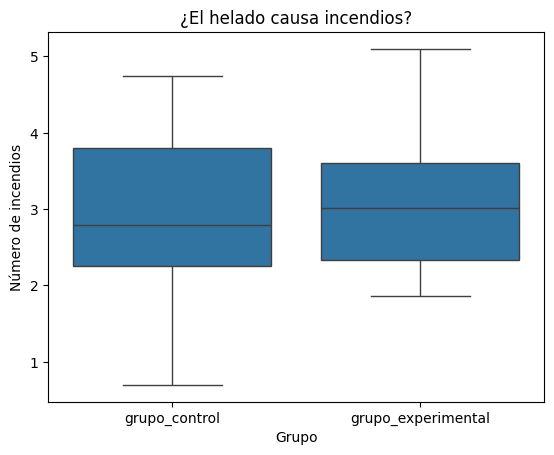

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="grupo", y="incendios", data=df_exp)
plt.title("¿El helado causa incendios?")
plt.ylabel("Número de incendios")
plt.xlabel("Grupo")
plt.show()

El promedio de incendios es ligeramente mayor en el grupo experimental (3.08 vs 2.94).

Las distribuciones de ambos grupos son similares (rango, mediana, presencia de valores extremos).

No hay una diferencia significativa visualmente ni en los promedios.
Aunque hay una correlación leve entre el consumo de helado y los incendios, no podemos afirmar que una causa al otro.

La diferencia entre grupos es muy pequeña y no hay evidencia clara de que reducir el consumo de helado baje los incendios.

Probablemente exista una tercera variable que explique ambos fenómenos, como el calor en verano, que aumenta el consumo de helado y también los incendios.



# EJERCICIO: Correlación de variables (ejercicio 4)

In [ ]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import statsmodels.formula.api as smf

# 1. CREAR UNA BASE DE DATOS SIMULADA
np.random.seed(1)
n = 100

# Variables independientes (predictoras)
horas_estudio = np.random.normal(5, 2, n).clip(0)    # horas de estudio
uso_celular = np.random.normal(3, 1, n).clip(0)      # horas de uso del celular

# Variable dependiente (respuesta)
# Nota simulada = 60 + (5 * horas_estudio) - (2 * uso_celular) + error aleatorio
notas = 60 + (horas_estudio * 5) - (uso_celular * 2) + np.random.normal(0, 5, n)


In [ ]:
# Crear el DataFrame
df = pd.DataFrame({
    'horas_estudio': horas_estudio,
    'uso_celular': uso_celular,
    'nota': notas
})
print(df)

    horas_estudio  uso_celular       nota
0        8.248691     2.552871  94.133320
1        3.776487     4.224508  74.553449
2        3.943656     3.403492  70.099772
3        2.854063     3.593579  76.857547
4        6.730815     1.905088  83.184142
..            ...          ...        ...
95       5.154680     1.372562  81.541468
96       4.312293     3.602319  76.443335
97       5.087194     3.420282  82.519257
98       3.759998     3.810952  66.400962
99       6.396064     4.044442  86.820988

[100 rows x 3 columns]


In [ ]:
# 2. ESTADÍSTICA DESCRIPTIVA
print("Estadística descriptiva:\n")
print(df.describe())

Estadística descriptiva:

       horas_estudio  uso_celular        nota
count     100.000000   100.000000  100.000000
mean        5.121166     3.152795   79.349348
std         1.779231     0.936690    9.906805
min         0.396923     0.565162   46.842405
25%         3.772365     2.699990   74.125557
50%         5.128148     3.236616   79.856379
75%         6.274821     3.743020   85.623941
max         9.371151     5.528326   97.918591


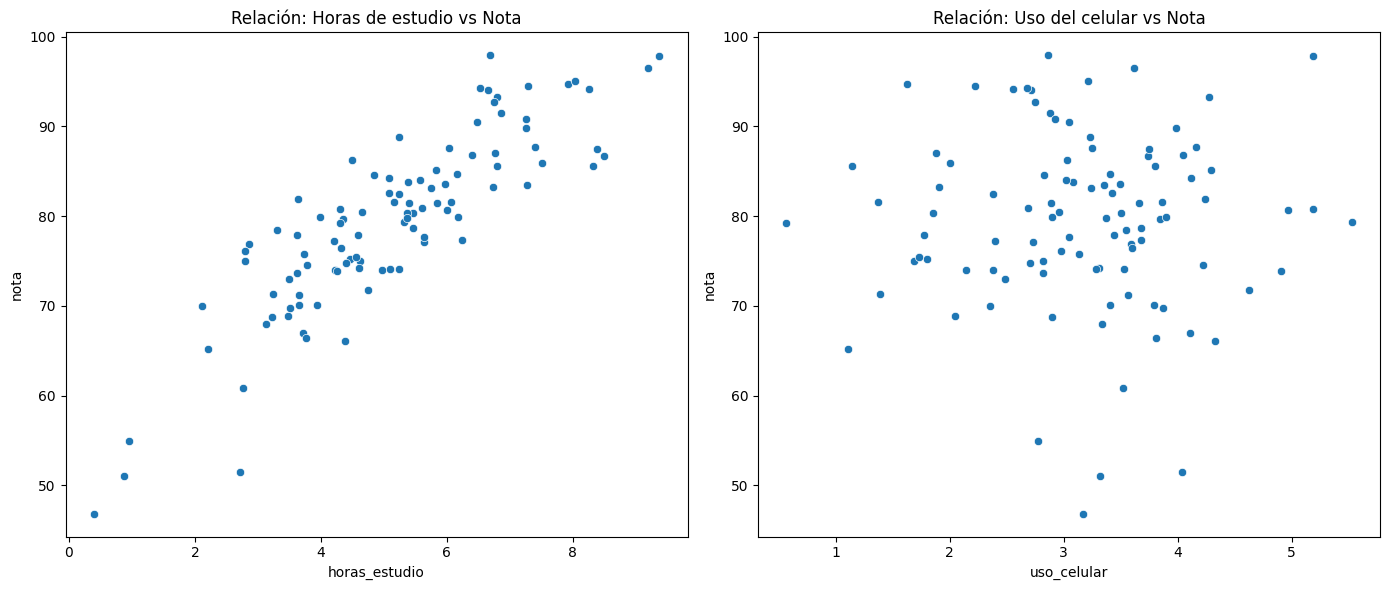


Matriz de correlación:
               horas_estudio  uso_celular      nota
horas_estudio       1.000000     0.090631  0.862411
uso_celular         0.090631     1.000000 -0.006998
nota                0.862411    -0.006998  1.000000

Correlación entre horas de estudio y nota: r = 0.86, p = 0.0000
Correlación entre uso del celular y nota: r = -0.01, p = 0.9449


In [ ]:
# 3. VISUALIZACIÓN DE DATOS
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='horas_estudio', y='nota')
plt.title('Relación: Horas de estudio vs Nota')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='uso_celular', y='nota')
plt.title('Relación: Uso del celular vs Nota')

plt.tight_layout()
plt.show()

# 4. CORRELACIÓN
print("\nMatriz de correlación:")
print(df.corr())

corr1, p1 = pearsonr(df['horas_estudio'], df['nota'])
corr2, p2 = pearsonr(df['uso_celular'], df['nota'])

print(f"\nCorrelación entre horas de estudio y nota: r = {corr1:.2f}, p = {p1:.4f}")
print(f"Correlación entre uso del celular y nota: r = {corr2:.2f}, p = {p2:.4f}")

In [ ]:
# 5. REGRESIÓN LINEAL MÚLTIPLE (para inferir posible causalidad)
modelo = smf.ols('nota ~ horas_estudio + uso_celular', data=df).fit()
print("\nResumen del modelo de regresión lineal:")
print(modelo.summary())


Resumen del modelo de regresión lineal:
                            OLS Regression Results                            
Dep. Variable:                   nota   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     146.3
Date:                Sun, 29 Jun 2025   Prob (F-statistic):           5.13e-30
Time:                        14:30:37   Log-Likelihood:                -301.19
No. Observations:                 100   AIC:                             608.4
Df Residuals:                      97   BIC:                             616.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Inter

# EJERCICIO: Correlación de variables (ejemplo 5)

In [ ]:
# Simulación de un estudio experimental para analizar causalidad
# ¿El ejercicio mejora la memoria?
# Simula un ensayo clínico simple con 100 personas.
# Divide a las personas en dos grupos: uno hace ejercicio y el otro no.
# Genera puntuaciones de memoria antes y después.
# Usa un gráfico y una prueba t de Student para ver si hay una diferencia estadística entre los grupos.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Fijamos una semilla para reproducibilidad
np.random.seed(42)
# 2. Creamos un DataFrame con 100 participantes
n = 100
data = pd.DataFrame()
data['participante'] = range(1, n+1)

In [ ]:
# 3. Asignamos aleatoriamente a los participantes a un grupo
# 0 = grupo control (no hace ejercicio), 1 = grupo experimental (sí hace ejercicio)
data['grupo'] = np.random.choice([0, 1], size=n)


In [ ]:
# 4. Simulamos puntuaciones de memoria iniciales (antes del experimento)
# Usamos una media de 70 y desviación estándar de 10
data['memoria_inicial'] = np.random.normal(loc=70, scale=10, size=n)

In [ ]:
# 5. Simulamos puntuaciones de memoria final
# - El grupo control no mejora (solo variación aleatoria)
# - El grupo experimental mejora en promedio 10 puntos
mejora = np.where(data['grupo'] == 1,
                  np.random.normal(10, 5, size=n),  # mejora media de 10
                  np.random.normal(0, 5, size=n))   # mejora media de 0
data['memoria_final'] = data['memoria_inicial'] + mejora

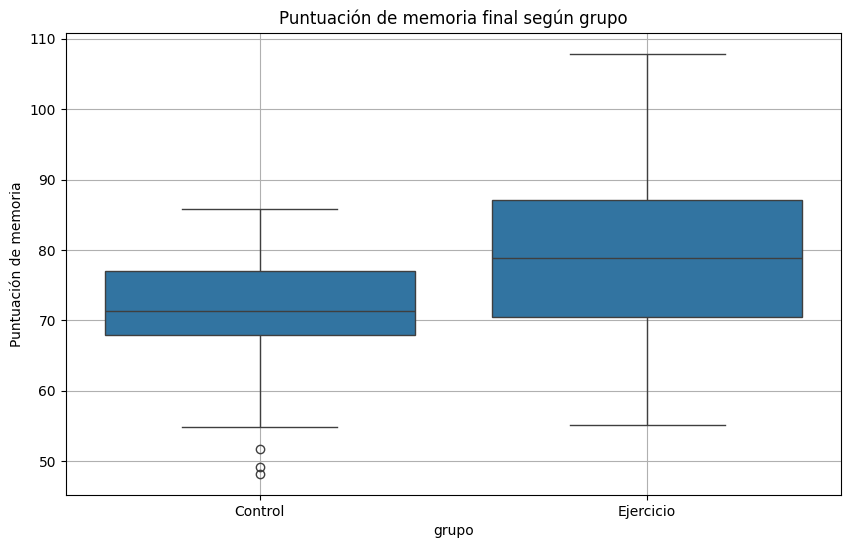

In [ ]:
# 6. Visualizamos los resultados
plt.figure(figsize=(10, 6))
sns.boxplot(x='grupo', y='memoria_final', data=data)
plt.xticks([0, 1], ['Control', 'Ejercicio'])
plt.title('Puntuación de memoria final según grupo')
plt.ylabel('Puntuación de memoria')
plt.grid(True)
plt.show()

In [ ]:
# 7. Prueba estadística: ¿hay diferencia significativa?
grupo_control = data[data['grupo'] == 0]['memoria_final']
grupo_ejercicio = data[data['grupo'] == 1]['memoria_final']

t_stat, p_value = stats.ttest_ind(grupo_ejercicio, grupo_control)

print(f'Estadístico t: {t_stat:.2f}')
print(f'Valor p: {p_value:.4f}')

if p_value < 0.05:
    print("✅ Hay evidencia estadística de que el ejercicio mejora la memoria.")
else:
    print("❌ No hay evidencia suficiente para afirmar que el ejercicio mejora la memoria.")

Estadístico t: 3.91
Valor p: 0.0002
✅ Hay evidencia estadística de que el ejercicio mejora la memoria.


In [ ]:
# Comparación entre correlación de Pearson y correlación de Spearman
# 1. Importar librerías
# =============================
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# 2. Semilla para reproducibilidad
# =============================
np.random.seed(42)

# =============================
# 3. Crear datos
# =============================
# Datos con relación no lineal (relación monótona pero no lineal)
x = np.arange(1, 100)
y = np.log(x) + np.random.normal(0, 0.1, len(x))  # Relación logarítmica + algo de ruido

# Crear DataFrame
df = pd.DataFrame({'x': x, 'y': y})

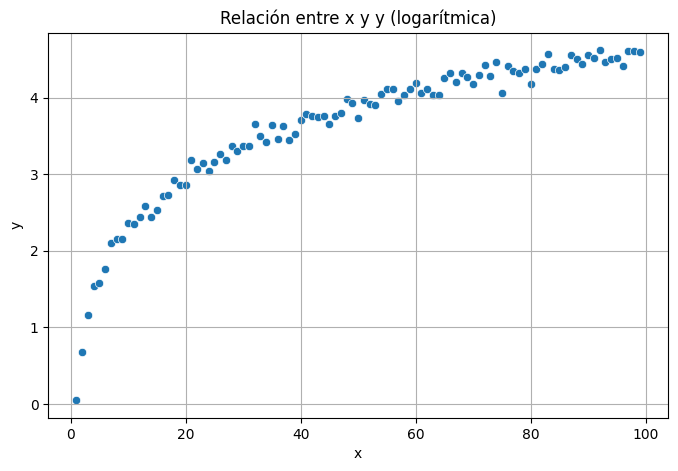

In [ ]:
# 4. Visualizar los datos
# =============================
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='x', y='y')
plt.title("Relación entre x y y (logarítmica)")
plt.grid(True)
plt.show()

In [ ]:
# 5. Calcular correlaciones
# =============================

# Pearson: mide relación lineal
pearson_corr, pearson_p = stats.pearsonr(df['x'], df['y'])

# Spearman: mide relación monótona (no necesariamente lineal)
spearman_corr, spearman_p = stats.spearmanr(df['x'], df['y'])

# 6. Mostrar resultados
# =============================
print(f"Correlación de Pearson: r = {pearson_corr:.3f}, p = {pearson_p:.4f}")
print(f"Correlación de Spearman: ρ = {spearman_corr:.3f}, p = {spearman_p:.4f}")

Correlación de Pearson: r = 0.899, p = 0.0000
Correlación de Spearman: ρ = 0.986, p = 0.0000


# EJERCICIO: Correlación de variables (ejemplo 6)

In [ ]:
# Ejemplo de correlación con variable ordinal
# ===============================

import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear un DataFrame con variables ordinales y continuas
np.random.seed(42)  # Para reproducibilidad

# Simulamos satisfacción en escala ordinal (1=muy insatisfecho, 5=muy satisfecho)
satisfaccion = np.random.choice([1, 2, 3, 4, 5], size=100, p=[0.1, 0.2, 0.3, 0.25, 0.15])
# Esto quiere decir que:

# el 30% de las veces se elegirá un 3,
# el 10% de las veces un 1,
# el 15% de las veces un 5,
# etc.
# Y la suma total de todas esas probabilidades debe ser 1 (o 100%).

# Simulamos horas de sueño con relación monótona positiva con satisfacción
horas_sueno = satisfaccion + np.random.normal(0, 0.5, size=100)  # Más satisfecho, duerme más

# Creamos el DataFrame
df = pd.DataFrame({
    'satisfaccion': satisfaccion,
    'horas_sueno': horas_sueno
})

# Mostramos las primeras filas
print(df.head())

   satisfaccion  horas_sueno
0             3     3.043524
1             5     4.850496
2             4     4.045880
3             3     2.006216
4             2     1.890164


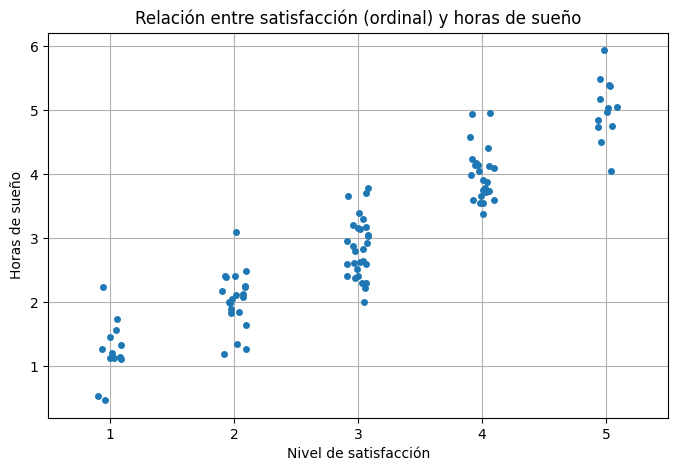

In [ ]:
# 2. Visualización con gráfico de dispersión
plt.figure(figsize=(8,5))
sns.stripplot(x='satisfaccion', y='horas_sueno', data=df, jitter=True)
plt.title('Relación entre satisfacción (ordinal) y horas de sueño')
plt.xlabel('Nivel de satisfacción')
plt.ylabel('Horas de sueño')
plt.grid(True)
plt.show()

In [ ]:
# 3. Correlación de Pearson
r_pearson, p_pearson = pearsonr(df['satisfaccion'], df['horas_sueno'])
print(f"Correlación de Pearson: r = {r_pearson:.2f}, p = {p_pearson:.4f}")
# r = 0.93: hay una correlación muy fuerte y positiva entre las dos variables. Esto quiere decir que a
# medida que una variable aumenta, la otra también tiende a aumentar de manera lineal.
# p = 0.0000: es muy significativa estadísticamente (p < 0.05), por lo tanto, es muy poco probable que
# esta relación haya ocurrido por azar.

# 4. Correlación de Spearman
r_spearman, p_spearman = spearmanr(df['satisfaccion'], df['horas_sueno'])
print(f"Correlación de Spearman: r = {r_spearman:.2f}, p = {p_spearman:.4f}")
# r = 0.94: también muestra una correlación muy fuerte y positiva, pero esta vez basada en los rangos de
# los datos, no en sus valores absolutos.
# Spearman es ideal cuando los datos son ordinales o no siguen una relación estrictamente lineal, sino
# monótona (crecen o decrecen, pero no necesariamente en línea recta).

Correlación de Pearson: r = 0.93, p = 0.0000
Correlación de Spearman: r = 0.94, p = 0.0000


In [ ]:
# 5. Interpretación sugerida
if p_spearman < 0.05:
    print("Existe una correlación significativa entre satisfacción y horas de sueño (Spearman).")
else:
    print("No hay evidencia suficiente de correlación (Spearman).")

Existe una correlación significativa entre satisfacción y horas de sueño (Spearman).


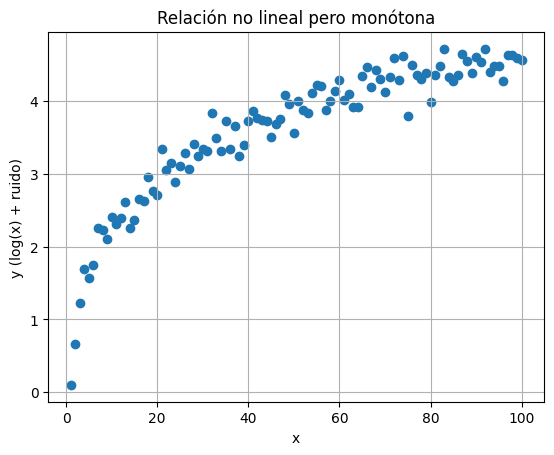

In [ ]:
# Ejemplo: Pearson bajo, Spearman alto

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Semilla para reproducibilidad
np.random.seed(42)

# Datos simulados: relación monótona creciente, pero no lineal (logarítmica)
x = np.linspace(1, 100, 100)
y = np.log(x) + np.random.normal(0, 0.2, 100)  # logarítmica + ruido

# Graficar
plt.scatter(x, y)
plt.title("Relación no lineal pero monótona")
plt.xlabel("x")
plt.ylabel("y (log(x) + ruido)")
plt.grid(True)
plt.show()

In [ ]:
# Correlaciones
pearson_r, p_pearson = stats.pearsonr(x, y)
spearman_r, p_spearman = stats.spearmanr(x, y)

# Resultados
print(f"Correlación de Pearson: r = {pearson_r:.2f}, p = {p_pearson:.4f}")
print(f"Correlación de Spearman: r = {spearman_r:.2f}, p = {p_spearman:.4f}")

Correlación de Pearson: r = 0.89, p = 0.0000
Correlación de Spearman: r = 0.96, p = 0.0000
